In [6]:
# Analysis parameters
select_region = 'MOs'
block = 'aud'
window_bin_slice = slice(3, 9)                            # bins 3 to 8 = 0 to 0.5 s after onset
weight_threshold = 0.005
outcome_filter = 1 # 0 (all trials) or 1 (trials with licking)
n_neurons = 0

# Plot styles
color1 = 'magenta'
color2 = 'turquoise'
color3 = 'purple'
colormap = 'RdPu'

In [7]:
import sys
sys.path.insert(0, '/code/src')

import pandas as pd 
import numpy as np
from datetime import datetime, date
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt
import time
from tqdm.auto import tqdm

import module
from module import decode_trial_identity
import importlib
importlib.reload(module)

from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

In [8]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = "api.allenneuraldynamics.org"
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(
   host=API_GATEWAY_HOST,
    version="v2",
   database=DATABASE,
   collection=COLLECTION,
)
print(docdb_api_client._base_url)

https://api.allenneuraldynamics.org/v2/metadata_index/data_assets


In [9]:
aggregate = [
  {
    "$match": {
      "data_description.project_name": "Dynamic Routing", 
      "data_description.data_level": "derived", 
      "processing.data_processes": {
        "$elemMatch": {
          "process_type": "File format conversion",
          "start_date_time": {"$regex": "^2026-08-04"}
        }
      }
    }
  },
  {
    "$project": {
      "name": 1, 
      "subject_id": "$data_description.subject_id",
      "genotype": "$subject.subject_details.genotype", 
      "date_of_birth": "$subject.subject_details.date_of_birth", 
      "sex": "$subject.subject_details.sex",  
      "session_start_time": "$acquisition.acquisition_start_time",
      "session_end_time": "$acquisition.acquisition_end_time", 
      "stimulus_epochs": "$acquisition.stimulus_epochs",
      "project_name": "$data_description.project_name", 
      "modality": "$data_description.modalities.name", 
      "targeted_structure": "$acquisition.data_streams.configurations.probes.primary_targeted_structure.name" 
    }
  },
]
    
records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)

# Extract performance metrics in Python
for r in records:
    dr = next((e for e in r.get("stimulus_epochs", []) if e.get("stimulus_name") == "DynamicRouting1"), None)
    r["dr_performance"] = dr["performance_metrics"] if dr else None

In [10]:
df = pd.DataFrame(records)
df['session_date'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).date(), axis=1)
df['session_start_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).time(), axis=1)
df['session_end_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_end_time']).time(), axis=1)
df['date_of_birth'] = df.apply(lambda x: datetime.strptime(x['date_of_birth'], '%Y-%m-%d').date(), axis=1)
df['age'] = df.apply(lambda x: (x['session_date'] - x['date_of_birth']).days, axis=1)

df['trials_total'] = df['dr_performance'].apply(lambda x: x['trials_total'] if x else None)
df['trials_rewarded'] = df['dr_performance'].apply(lambda x: x['trials_rewarded'] if x else None)
df['reward_rate'] = df['trials_rewarded'] / df['trials_total']
df['reward_consumed_mL'] = df['dr_performance'].apply(lambda x: x['reward_consumed_during_epoch'] if x else None)
df['block_metrics'] = df['dr_performance'].apply(lambda x: x['output_parameters']['block_metrics'] if x else None)
df['mean_dprime_same_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_same_modal'] for b in x.values()]).mean() if x else None
)
df['mean_dprime_other_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_other_modal_go'] for b in x.values()]).mean() if x else None
)

order = ['project_name', '_id', 'name', 'subject_id', 'genotype', 'date_of_birth', 'age', 'sex',
         'modality', 'session_date', 'session_start_time', 'session_end_time', 'targeted_structure',
         'trials_total', 'trials_rewarded', 'reward_rate', 'reward_consumed_mL',
         'mean_dprime_same_modal', 'mean_dprime_other_modal']
df = df[order].sort_values(by='subject_id')
df

,project_name,_id,name,subject_id,genotype,date_of_birth,age,sex,modality,session_date,session_start_time,session_end_time,targeted_structure,trials_total,trials_rewarded,reward_rate,reward_consumed_mL,mean_dprime_same_modal,mean_dprime_other_modal
2,Dynamic Routing,66dc0f20-45dc-4a65-ac3a-0a04ac0e1df4,ecephys_662892_2023-08-24_14-28-28_nwb_2026-08...,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2022-12-24,243,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-08-24,14:28:28,16:28:14.588745,"[[[Piriform area], [root]]]",476,123,0.258403,3.8400000000000016,2.152875,2.209537
6,Dynamic Routing,0f42545e-0e5f-4dfc-9777-8070c1e69ffd,ecephys_664851_2023-11-16_12-54-53_nwb_2026-08...,664851,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-01-09,311,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-11-16,12:54:53,14:46:25.481437,"[[[Secondary motor area], [Field CA1], [Subicu...",527,139,0.263757,4.35,3.133879,2.593231
3,Dynamic Routing,468a63e1-6e2f-494e-8448-f8bf07afcad5,ecephys_667252_2023-09-28_15-00-38_nwb_2026-08...,667252,wt/wt,2023-01-27,244,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-09-28,15:00:38,17:03:03.333877,"[[[Secondary motor area], [Primary motor area]...",486,123,0.253086,3.7800000000000002,3.261005,2.260717
10,Dynamic Routing,b0377871-8621-45b2-8c31-a3957d669787,ecephys_708016_2024-04-29_12-59-12_nwb_2026-08...,708016,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-10-18,194,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-04-29,12:59:12,15:00:31.755703,"[[[Secondary motor area], [Primary somatosenso...",533,129,0.242026,4.049999999999999,3.027970,2.665116
11,Dynamic Routing,ada82eb8-3f9c-4c80-9dbe-30b25114a391,ecephys_712815_2024-05-22_12-26-32_nwb_2026-08...,712815,wt/wt,2023-11-17,187,Female,"[Extracellular electrophysiology, Behavior, Be...",2024-05-22,12:26:32,14:23:25.111009,"[[[Dentate gyrus], [Posterior complex of the t...",545,138,0.253211,4.17,2.988601,1.745163
5,Dynamic Routing,1055573d-b0f0-4b31-a648-131ccddff1c8,ecephys_713655_2024-08-09_10-41-47_nwb_2026-08...,713655,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-11-23,260,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-08-09,10:41:47,12:49:52.580059,"[[[Anterodorsal nucleus], [Supplemental somato...",515,129,0.250485,4.02,2.841083,3.002527
8,Dynamic Routing,6baeab62-02b8-4de7-8ca4-2ab5da7e0f20,ecephys_714748_2024-06-24_12-52-23_nwb_2026-08...,714748,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-12-01,206,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-06-24,12:52:23,14:59:27.907510,"[[[Supplemental somatosensory area], [Secondar...",550,134,0.243636,4.229999999999999,3.329563,2.693473
9,Dynamic Routing,5a958ba6-ebe7-400a-8021-3230170e6638,ecephys_715710_2024-07-16_12-58-34_nwb_2026-08...,715710,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-12-07,222,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-07-16,12:58:34,15:05:31.280219,"[[[Supplemental somatosensory area], [Midbrain...",548,131,0.239051,4.049999999999999,2.032598,1.928238
7,Dynamic Routing,6774fb39-4c19-4ba2-99f5-2609fb1b9d77,ecephys_741137_2024-10-10_13-15-50_nwb_2026-08...,741137,wt/wt,2024-03-19,205,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-10-10,13:15:50,15:19:11.275413,"[[[Retrosplenial area, dorsal part], [Suppleme...",543,124,0.228361,5.2,3.113432,2.623589
0,Dynamic Routing,c5bc8e0e-81ee-4e52-a7b6-90089b0dfc5f,ecephys_742903_2024-10-23_14-12-23_nwb_2026-08...,742903,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2024-05-16,160,Female,"[Extracellular electrophysiology, Behavior, Be...",2024-10-23,14:12:23,16:15:54.652646,"[[[Primary somatosensory area], [Caudoputamen]...",489,124,0.253579,5.2,3.177007,2.342171


In [11]:
rows = []
mouse_bar = tqdm(list(df.iterrows()), desc="mice", unit="mouse")
for _, m in mouse_bar:
    mouse_bar.set_postfix_str(f"subject {m['subject_id']}")

    nwb_path = f"/data/dynamicrouting_datacube/{m['name']}/{m['name'][8:25]}.nwb.zarr"
    t0 = time.time()
    nwbfile = pynwb.read_nwb(nwb_path)                       # open once per mouse
    units = nwbfile.units.to_dataframe()
    regions = sorted(units.loc[units.default_qc, 'structure'].unique())
    tqdm.write(f"\n{m['subject_id']}: {len(regions)} candidate regions "
               f"({time.time() - t0:.0f}s to load)")

    for region in tqdm(regions, desc=f"{m['subject_id']} regions",
                       unit="region", leave=False):
        r = decode_trial_identity(
            nwbfile, region, block='aud',
            outcome_filter=1, window_bin_slice=slice(3, 9),
            n_neurons=50, n_trials=10,
            min_units=50, min_trials_per_class=10,
            mouse_id=m['subject_id'])
        rows.append(r)

        if r['status'] == 'ok':
            tqdm.write(f"  {region:<8} ok    {r['n_units']:>3} units  "
                       f"cv {r['cv_accuracy_mean']:.2f}  (chance {r['chance']:.2f})")
        else:
            tqdm.write(f"  {region:<8} skip  {r['status']}  "
                       f"({r['n_units']} units, "
                       f"{r['n_rew_trials']}+{r['n_unrew_trials']} trials)")

    n_ok = sum(x['mouse_id'] == m['subject_id'] and x['status'] == 'ok'
               for x in rows)
    tqdm.write(f"{m['subject_id']}: {n_ok}/{len(regions)} regions decoded")

results = pd.DataFrame(rows)
ok = results[results.status == 'ok']
print(f"\ndone: {len(ok)}/{len(results)} region-sessions decoded "
      f"across {results.mouse_id.nunique()} mice")


mice:   0%|          | 0/12 [00:00<?, ?mouse/s, subject 662892]/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (430361, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (430350, 500) float32 read-only>
  warnings.warn(
mice:   0%|          | 0/12 [00:43<?, ?mouse/s, subject 662892]


662892: 14 candidate regions (43s to load)


                                                               
mice:   0%|          | 0/12 [00:50<?, ?mouse/s, subject 662892]

  AId      skip  insufficient_units  (16 units, 0+0 trials)


                                                               
mice:   0%|          | 0/12 [00:56<?, ?mouse/s, subject 662892]   

...

  TTd      skip  insufficient_units  (42 units, 0+0 trials)


                                                                         
mice:  92%|█████████▏| 11/12 [50:58<05:15, 315.63s/mouse, subject 759434]

  VISli    skip  insufficient_units  (2 units, 0+0 trials)


                                                                         
mice: 100%|██████████| 12/12 [51:08<00:00, 255.75s/mouse, subject 759434]

  scwm     skip  insufficient_units  (1 units, 0+0 trials)
759434: 3/15 regions decoded

done: 36/227 region-sessions decoded across 12 mice


In [12]:
ok

,mouse_id,region,block,n_units,n_rew_trials,n_unrew_trials,n_trials,status,split_accuracy,cv_accuracy_mean,cv_accuracy_folds,n_cv_folds,chance,confusion_matrix,confusion_labels,coef_weights,unit_ids
9,662892,ORBl,aud,50,10,10,20,ok,0.8,0.75,"[0.75, 0.75, 0.75, 0.75, 0.75]",5.0,0.5,"[[7, 3], [2, 8]]","[sound1, vis1]","[0.03291176106413049, 0.03861412586676542, 0.0...","[322, 325, 329, 332, 339, 344, 346, 355, 357, ..."
11,662892,PIR,aud,50,10,10,20,ok,0.8,0.80,"[0.5, 0.5, 1.0, 1.0, 1.0]",5.0,0.5,"[[9, 1], [3, 7]]","[sound1, vis1]","[0.011519509502205228, 0.01654479511131421, 0....","[42, 43, 45, 48, 53, 55, 58, 63, 77, 84, 88, 9..."
14,664851,ACAd,aud,50,10,10,20,ok,1.0,1.00,"[1.0, 1.0, 1.0, 1.0, 1.0]",5.0,0.5,"[[10, 0], [0, 10]]","[sound1, vis1]","[0.02441163252180001, 0.008187018544429941, 0....","[31, 35, 40, 43, 44, 48, 55, 58, 59, 64, 65, 7..."
24,664851,MOs,aud,50,10,10,20,ok,1.0,1.00,"[1.0, 1.0, 1.0, 1.0, 1.0]",5.0,0.5,"[[10, 0], [0, 10]]","[sound1, vis1]","[0.03153965768817243, 0.005376755932414012, 0....","[98, 103, 104, 106, 110, 120, 126, 130, 139, 1..."
28,664851,PL,aud,50,10,10,20,ok,1.0,1.00,"[1.0, 1.0, 1.0, 1.0, 1.0]",5.0,0.5,"[[10, 0], [0, 10]]","[sound1, vis1]","[0.014615640819355772, 0.010974746002259514, 0...","[1163, 1165, 1166, 1167, 1170, 1174, 1180, 118..."
31,664851,SUB,aud,50,10,10,20,ok,0.8,0.60,"[0.5, 0.75, 0.25, 0.75, 0.75]",5.0,0.5,"[[7, 3], [5, 5]]","[sound1, vis1]","[0.040399212625252354, 0.04191235633645228, 0....","[852, 853, 854, 856, 859, 873, 874, 879, 882, ..."
37,667252,MOp,aud,50,10,10,20,ok,1.0,0.95,"[1.0, 1.0, 0.75, 1.0, 1.0]",5.0,0.5,"[[10, 0], [1, 9]]","[sound1, vis1]","[0.0007872814159991834, 0.0, 0.018587567967338...","[191, 193, 202, 205, 208, 214, 215, 219, 222, ..."
38,667252,MOs,aud,50,10,10,20,ok,1.0,0.90,"[1.0, 0.75, 0.75, 1.0, 1.0]",5.0,0.5,"[[8, 2], [0, 10]]","[sound1, vis1]","[0.041501569310729396, 0.00883137022744215, 0....","[2, 4, 5, 10, 13, 14, 20, 23, 28, 35, 42, 74, ..."
40,667252,ProS,aud,50,10,10,20,ok,1.0,1.00,"[1.0, 1.0, 1.0, 1.0, 1.0]",5.0,0.5,"[[10, 0], [0, 10]]","[sound1, vis1]","[0.002508349785337038, 0.0014848033925734638, ...","[510, 514, 516, 518, 521, 523, 527, 529, 536, ..."
41,667252,VISp,aud,50,10,10,20,ok,1.0,1.00,"[1.0, 1.0, 1.0, 1.0, 1.0]",5.0,0.5,"[[10, 0], [0, 10]]","[sound1, vis1]","[0.001616658320927063, 0.02845386463117064, 0....","[600, 601, 608, 611, 613, 615, 616, 619, 620, ..."


## Decoding accuracy by region

Built from the `ok` rows (region-sessions that passed the unit- and
trial-count thresholds). The decoding metric is the cross-validated accuracy
(`cv_accuracy_mean`); `chance` is the majority-class fraction for that session.

In [13]:
# Per-region summary across sessions / mice
acc_col = 'cv_accuracy_mean'

plot_df = ok.dropna(subset=[acc_col]).copy()
plot_df['acc_above_chance'] = plot_df[acc_col] - plot_df['chance']

def _sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

region_summary = (
    plot_df.groupby('region')
    .agg(mean_acc=(acc_col, 'mean'),
         sem_acc=(acc_col, _sem),
         mean_above_chance=('acc_above_chance', 'mean'),
         sem_above_chance=('acc_above_chance', _sem),
         mean_chance=('chance', 'mean'),
         n_sessions=(acc_col, 'size'),
         n_mice=('mouse_id', 'nunique'))
    .sort_values('mean_acc', ascending=False)
)
region_summary


,mean_acc,sem_acc,mean_above_chance,sem_above_chance,mean_chance,n_sessions,n_mice
region,,,,,,,
AUDpo,1.000000,0.000000,0.500000,0.000000,0.5,1,1
ProS,1.000000,0.000000,0.500000,0.000000,0.5,1,1
VISp,1.000000,0.000000,0.500000,0.000000,0.5,1,1
PL,0.966667,0.033333,0.466667,0.033333,0.5,3,3
MOs,0.950000,0.021822,0.450000,0.021822,0.5,7,7
CP,0.950000,0.028868,0.450000,0.028868,0.5,3,3
ACAd,0.950000,0.050000,0.450000,0.050000,0.5,2,2
AId,0.900000,0.000000,0.400000,0.000000,0.5,1,1
ORBl,0.866667,0.060093,0.366667,0.060093,0.5,3,3


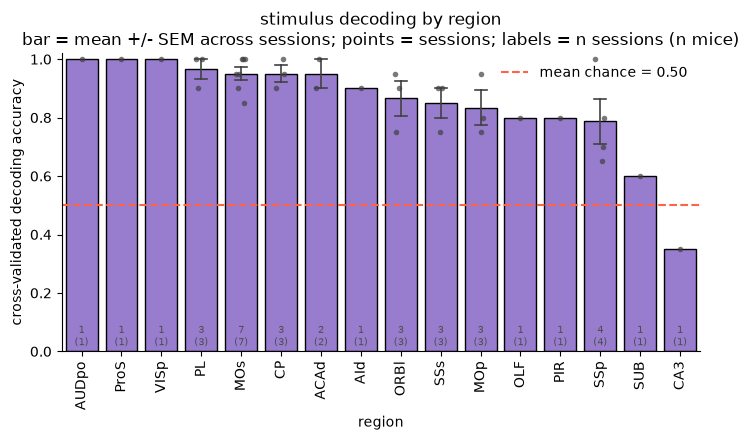

In [14]:
# Main plot: mean decoding accuracy per region (mean +/- SEM across sessions),
# with individual session points and the mean chance level.
order = region_summary.index.tolist()

fig, ax = plt.subplots(figsize=(max(6, 0.45 * len(order)), 4.5))

sns.barplot(data=plot_df, x='region', y=acc_col, order=order,
            color='mediumpurple', edgecolor='black', errorbar='se',
            capsize=0.3, err_kws={'linewidth': 1.2}, ax=ax)
sns.stripplot(data=plot_df, x='region', y=acc_col, order=order,
              color='0.25', size=4, jitter=0.15, alpha=0.7, ax=ax)

ax.axhline(plot_df['chance'].mean(), ls='--', color='tomato', linewidth=1.5,
           label=f"mean chance = {plot_df['chance'].mean():.2f}")

# annotate n sessions (n mice) under each bar
for xi, region in enumerate(order):
    row = region_summary.loc[region]
    ax.text(xi, 0.01, f"{int(row.n_sessions)}\n({int(row.n_mice)})",
            ha='center', va='bottom', fontsize=7, color='0.3')

ax.set_ylim(0, 1.02)
ax.set_xlabel('region')
ax.set_ylabel('cross-validated decoding accuracy')
ax.set_title('stimulus decoding by region\nbar = mean +/- SEM across sessions; '
             'points = sessions; labels = n sessions (n mice)')
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper right', frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


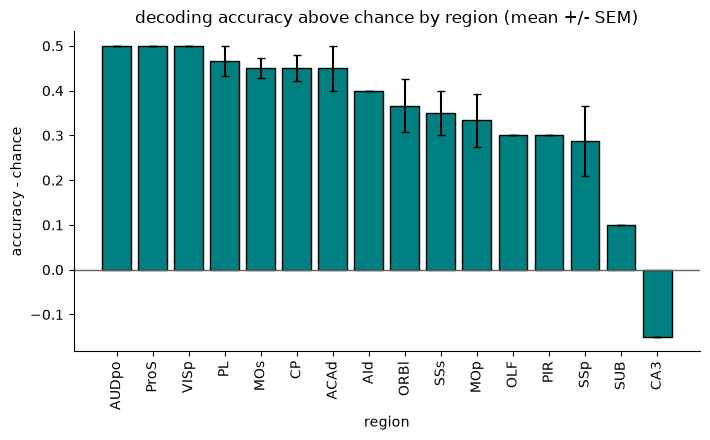

In [15]:
# Accuracy above chance per region (removes differences in class balance
# between sessions). Regions whose CI clears 0 decode above chance.
fig, ax = plt.subplots(figsize=(max(6, 0.45 * len(order)), 4.5))

ax.bar(np.arange(len(order)), region_summary['mean_above_chance'],
       yerr=region_summary['sem_above_chance'], capsize=3,
       color='teal', edgecolor='black')
ax.axhline(0, color='0.4', linewidth=1)
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(order, rotation=90)
ax.set_xlabel('region')
ax.set_ylabel('accuracy - chance')
ax.set_title('decoding accuracy above chance by region (mean +/- SEM)')
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


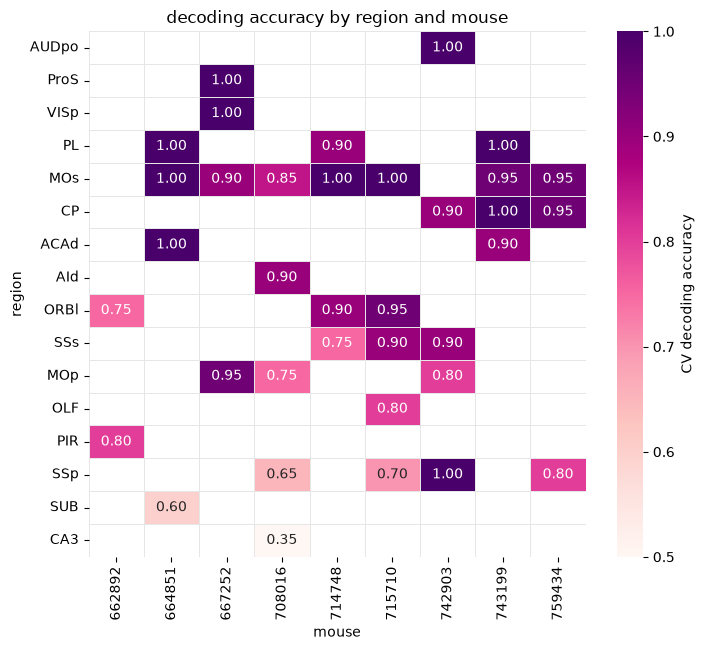

In [16]:
# Region x mouse heatmap: shows how consistent decoding is across mice and
# which region/mouse combinations were actually sampled (white = not available).
acc_matrix = plot_df.pivot_table(index='region', columns='mouse_id',
                                 values=acc_col, aggfunc='mean')
acc_matrix = acc_matrix.loc[order]

fig, ax = plt.subplots(figsize=(1 + 0.7 * acc_matrix.shape[1],
                                1 + 0.35 * acc_matrix.shape[0]))
sns.heatmap(acc_matrix, cmap='RdPu', vmin=0.5, vmax=1.0, annot=True, fmt='.2f',
            linewidths=0.5, linecolor='0.9',
            cbar_kws={'label': 'CV decoding accuracy'}, ax=ax)
ax.set_xlabel('mouse')
ax.set_ylabel('region')
ax.set_title('decoding accuracy by region and mouse')
fig.tight_layout()
plt.show()


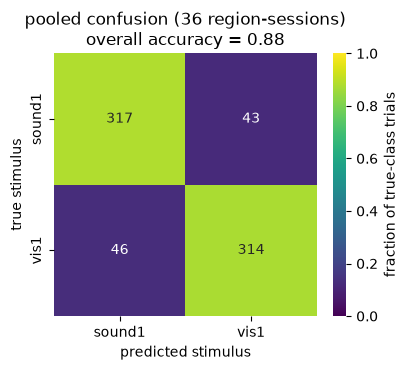

In [17]:
# Pooled confusion matrix across all ok region-sessions (cross-validated
# predictions summed, then row-normalised).
conf_labels = plot_df['confusion_labels'].iloc[0]
conf_total = np.sum(np.stack(plot_df['confusion_matrix'].values), axis=0)
conf_frac = conf_total / conf_total.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(4.2, 3.8))
sns.heatmap(conf_frac, annot=conf_total, fmt='d', cmap='viridis',
            vmin=0, vmax=1, xticklabels=conf_labels, yticklabels=conf_labels,
            cbar_kws={'label': 'fraction of true-class trials'}, ax=ax)
ax.set_xlabel('predicted stimulus')
ax.set_ylabel('true stimulus')
ax.set_title(f'pooled confusion ({len(plot_df)} region-sessions)\n'
             f'overall accuracy = {np.diag(conf_total).sum() / conf_total.sum():.2f}')
fig.tight_layout()
plt.show()
